In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

c:\Users\Asus\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:


df = pd.read_csv(r"C:/Users/Asus/Documents/prj/Human Complexity AI/data/student-mat.csv", sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [4]:
# Missing Value Check
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
# Risk Category
df['risk_level'] = df['G3'].apply(
    lambda x: 'High Risk' if x < 10 else 'Low Risk'
)

Human Complexity Feature Engineering

In [6]:
# 1. Socioeconomic Score
df['socioeconomic_score'] = (
    df['Medu'] +
    df['Fedu']
)


In [7]:
# 2. Lifestyle Risk Score
df['lifestyle_risk'] = (
    df['Walc'] +
    df['Dalc'] +
    df['goout']
)


In [8]:
# 3. Academic Engagement Score
df['engagement_score'] = (
    df['studytime'] -
    df['absences']/10
)

                                                            Exploratory Data Analysis

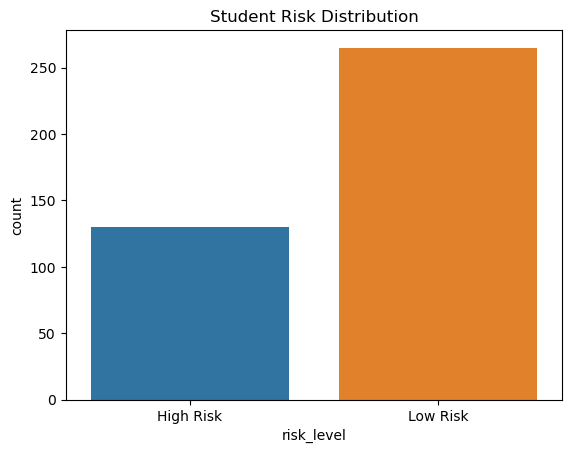

In [9]:
# 1. Risk Distribution
sns.countplot(x='risk_level', data=df)
plt.title("Student Risk Distribution")
plt.show()

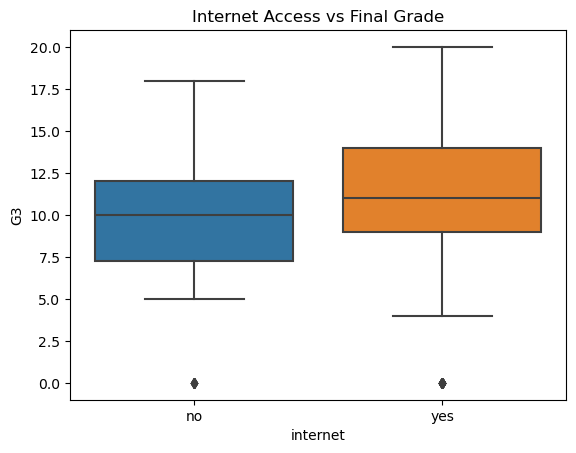

In [10]:
# 2. Internet Access vs Performance
sns.boxplot(x='internet', y='G3', data=df)
plt.title("Internet Access vs Final Grade")
plt.show()


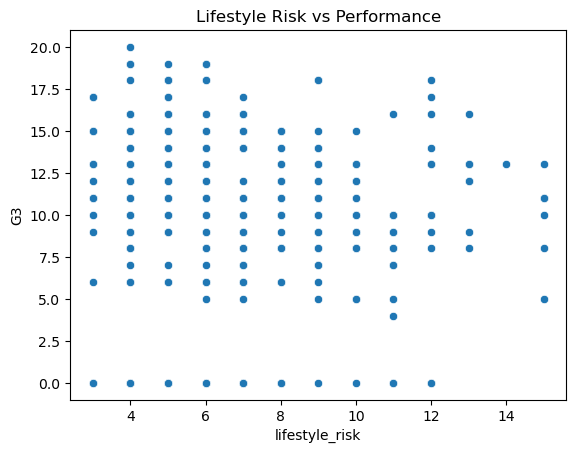

In [11]:
# 3. Stress/Lifestyle Analysis
sns.scatterplot(
    x='lifestyle_risk',
    y='G3',
    data=df
)
plt.title("Lifestyle Risk vs Performance")
plt.show()


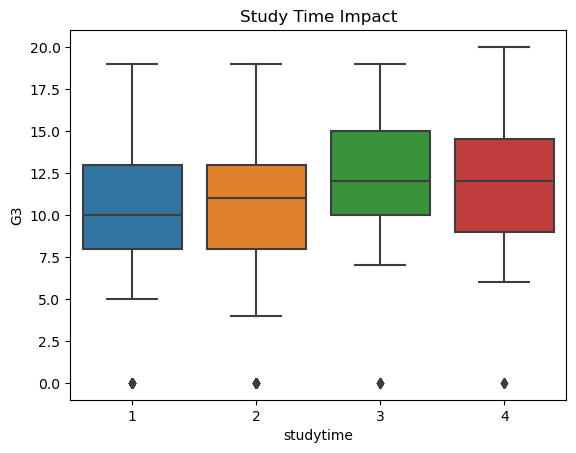

In [12]:
# 4. Study Time Analysis
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time Impact")
plt.show()


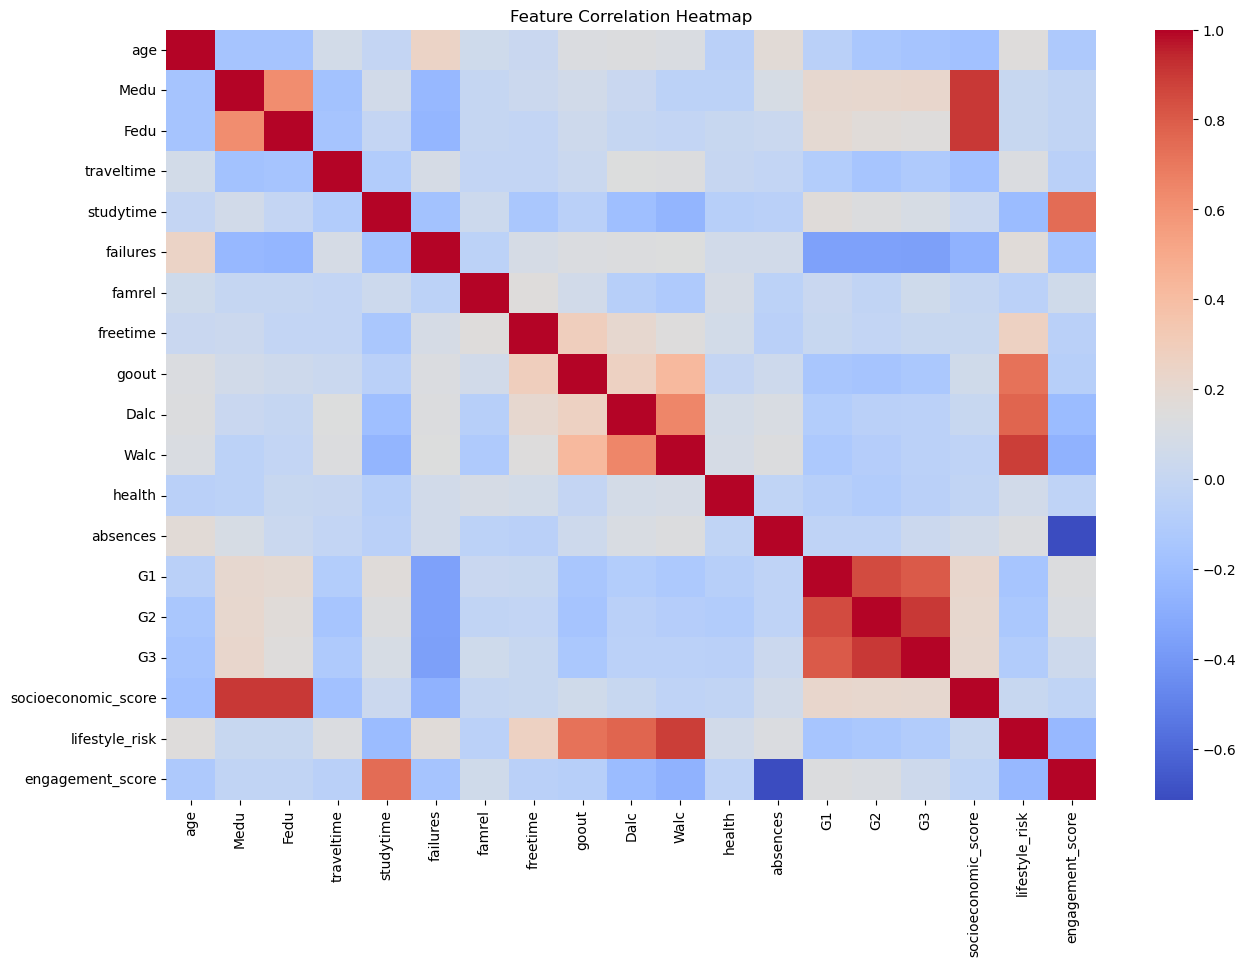

In [13]:
# 5. Correlation Heatmap
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

Bias Exploration

In [14]:
df.groupby('socioeconomic_score')['G3'].mean()

socioeconomic_score
1    12.500000
2     8.641026
3     9.255814
4     9.597222
5    10.404255
6    11.296875
7    10.948276
8    11.657143
Name: G3, dtype: float64

In [ ]:
# Key Insights Section



# Examples:

# Internet access improves average performance.
# Higher absence rate correlates with lower engagement.
# Lifestyle risk negatively impacts academic scores.
# Socioeconomic conditions influence outcomes.

# This is your:

# “Rethinking Traditional Data Science” argument.

In [18]:
df.to_csv(r"C:\Users\Asus\Documents\prj\Human Complexity AI\data\processed_data.csv", index=False)